<a href="https://colab.research.google.com/github/dhuuh19/Power-System-Economics/blob/main/Economic_Dispatch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cvxpy as cp
import numpy as np

# --- 1) 데이터: Kirschen 2판 Table 5.4 ---
names = ["A", "B", "C", "D"]
mc    = np.array([7.5, 6.0, 14.0, 10.0])   # 한계비용 [$/MWh]
pmax  = np.array([140, 285, 90, 85])       # 설비용량 [MW]
D     = 410                                # 총수요 [MW]

# --- 2) 결정변수 ---
P = cp.Variable(4)                         # 각 발전기 출력

# --- 3) 목적함수: 총비용 최소화 ---
cost = mc @ P                              # sum(mc_i * P_i)

# --- 4) 제약 ---
balance = cp.sum(P) == D                   # 수급균형 (이 제약의 dual이 λ=SMP)
limits  = [P >= 0, P <= pmax]

# --- 5) 풀기 ---
prob = cp.Problem(cp.Minimize(cost), [balance] + limits)
prob.solve()

# --- 6) 결과 읽기 ---
print("상태:", prob.status)
for n, p in zip(names, P.value):
    print(f"  발전기 {n}: {p:6.1f} MW")
print(f"총비용: {prob.value:.2f} $/h")        # 기대값: 2647.50
print(f"SMP(λ): {balance.dual_value:.2f} $/MWh")

상태: optimal
  발전기 A:  125.0 MW
  발전기 B:  285.0 MW
  발전기 C:    0.0 MW
  발전기 D:    0.0 MW
총비용: 2647.50 $/h
SMP(λ): -7.50 $/MWh


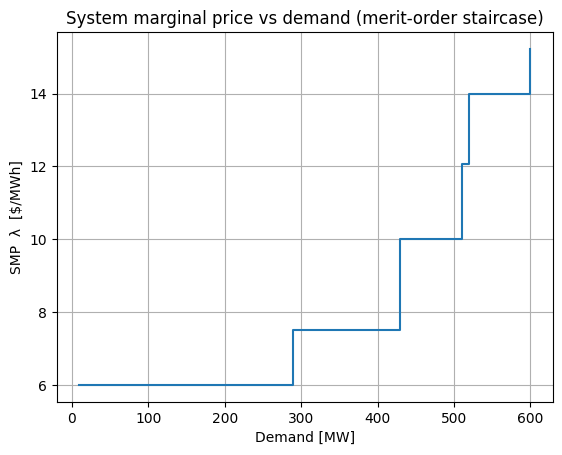

In [ ]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

mc   = np.array([7.5, 6.0, 14.0, 10.0])
pmax = np.array([140, 285, 90, 85])

def solve_ed(D):
    """수요 D에 대한 경제급전. (상태, 총비용, SMP) 반환"""
    P = cp.Variable(4)
    balance = cp.sum(P) == D
    prob = cp.Problem(cp.Minimize(mc @ P), [balance, P >= 0, P <= pmax])
    prob.solve()
    if prob.status != "optimal":
        return prob.status, None, None
    return prob.status, prob.value, abs(balance.dual_value)
    # abs()를 쓴 이유: CVXPY는 제약을 쓰는 방향에 따라 dual 부호가
    # 반대로 나올 수 있음. 왜 그런지 부호 관례를 직접 조사해 README에
    # 정리해 보면 좋은 '씨름의 흔적'이 됨.

demands = np.arange(10, 601, 10)
smps = [solve_ed(D)[2] for D in demands]

plt.step(demands, smps, where="post")
plt.xlabel("Demand [MW]"); plt.ylabel("SMP  λ  [$/MWh]")
plt.title("System marginal price vs demand (merit-order staircase)")
plt.grid(True); plt.show()

In [ ]:
VOLL = 3500.0   # Value of Lost Load [$/MWh] — 정전의 사회적 비용.
                # 관할권마다 수천$/MWh 수준으로 추정치가 다름 (Kirschen Ch6의
                # 참고문헌들이 다루는 주제). 여기선 예시값.

def solve_ed_voll(D):
    P    = cp.Variable(4)
    shed = cp.Variable(nonneg=True)          # 차단되는 부하량 [MW]
    balance = cp.sum(P) + shed == D          # 발전 + 차단 = 수요
    cost = mc @ P + VOLL * shed
    prob = cp.Problem(cp.Minimize(cost), [balance, P >= 0, P <= pmax])
    prob.solve()
    return prob.value, abs(balance.dual_value), shed.value

In [ ]:
a = np.array([7.5, 6.0, 14.0, 10.0])      # 선형 계수 [$/MWh]
b = np.array([0.010, 0.005, 0.020, 0.015]) # 이차 계수 [$/MW²h] (임의의 합리적 값)

def solve_ed_quad(D):
    P = cp.Variable(4)
    balance = cp.sum(P) == D
    cost = a @ P + cp.sum(cp.multiply(b, cp.square(P)))
    prob = cp.Problem(cp.Minimize(cost), [balance, P >= 0, P <= pmax])
    prob.solve()
    lam = abs(balance.dual_value)
    inc_cost = a + 2 * b * P.value           # 각 발전기의 증분비용
    return lam, P.value, inc_cost

In [ ]:
e, f = 20.0, 0.02        # 역수요: π = 20 − 0.02 q

P = cp.Variable(4)
q = cp.Variable(nonneg=True)               # 소비량 자체가 결정변수!
balance = cp.sum(P) == q
gross_surplus = e * q - 0.5 * f * cp.square(q)
welfare = gross_surplus - mc @ P
prob = cp.Problem(cp.Maximize(welfare), [balance, P >= 0, P <= pmax])
prob.solve()

print("소비량 q* =", q.value)
print("λ =", abs(balance.dual_value))
print("시장가격 π(q*) =", e - f * q.value)

소비량 q* = 499.9999999954366
λ = 10.00000000004535
시장가격 π(q*) = 10.000000000091267
